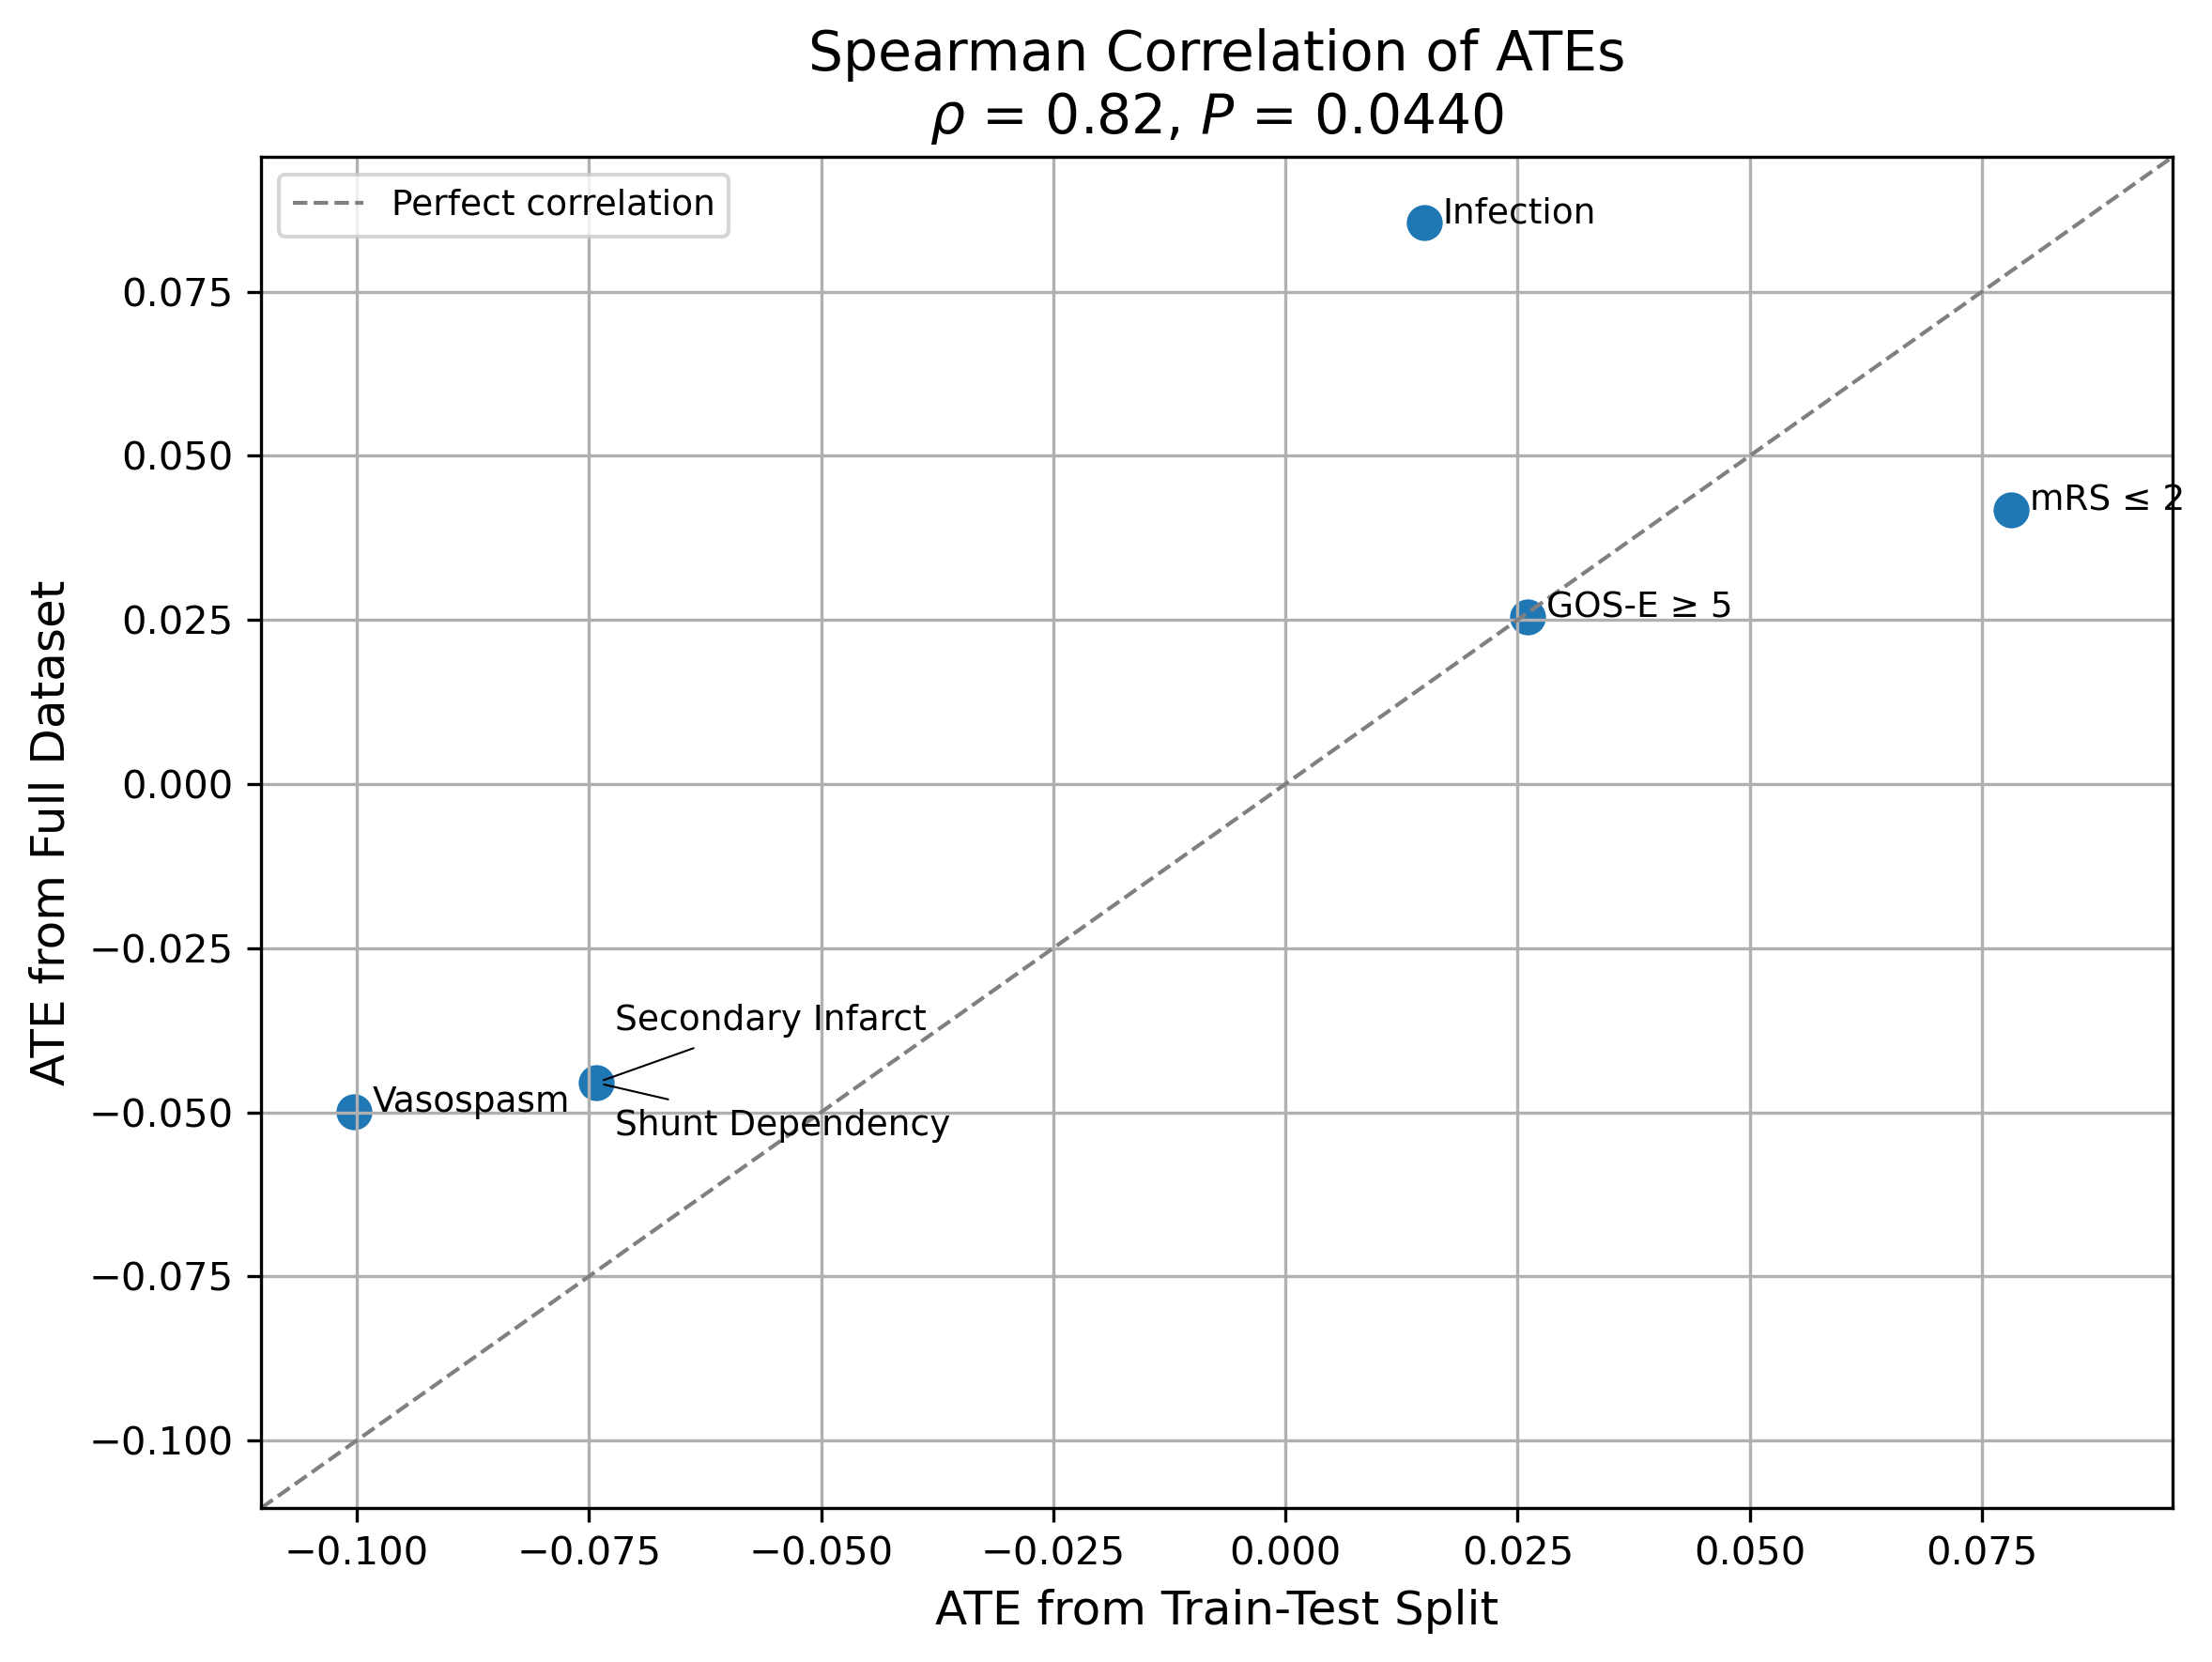

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Define outcomes and ATEs
outcomes = [
    "Vasospasm",
    "Secondary Infarct",
    "Infection",
    "mRS ≤ 2",
    "GOS-E ≥ 5",
    "Shunt Dependency"
]

ate_test = [-0.1003, -0.0742,  0.0149, 0.0781, 0.0261, -0.0742]
ate_full = [-0.0499, -0.0455, 0.0855, 0.0417, 0.0254, -0.0455]

# Compute Spearman rank correlation
rho, pval = spearmanr(ate_test, ate_full)

# Plotting
plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(x=ate_test, y=ate_full, s=100)

# Add identity line (x = y)
lims = [
    min(min(ate_test), min(ate_full)) - 0.01,
    max(max(ate_test), max(ate_full)) + 0.01,
]
plt.plot(lims, lims, ls="--", c="gray", lw=1, label="Perfect correlation")
plt.xlim(lims)
plt.ylim(lims)

# Annotate each point, offset overlapping ones
offsets = {
    "Shunt Dependency": (0.002, -0.008),
    "Secondary Infarct": (0.002, 0.008)
}

for i, label in enumerate(outcomes):
    x, y = ate_test[i], ate_full[i]
    if label in offsets:
        dx, dy = offsets[label]
        plt.annotate(label,
                     (x, y), 
                     xytext=(x + dx, y + dy),
                     arrowprops=dict(arrowstyle='-', lw=0.5),
                     fontsize=9)
    else:
        plt.text(x + 0.002, y, label, fontsize=9)

# Axis labels and title
plt.title(rf"Spearman Correlation of ATEs" + "\n" + rf"$\rho$ = {rho:.2f}, " + rf"$\it{{P}}$ = {pval:.4f}", fontsize=14)
plt.xlabel("ATE from Train-Test Split", fontsize=12)
plt.ylabel("ATE from Full Dataset", fontsize=12)
plt.legend(loc="upper left", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()
